# Quels facteurs sont associés à la régularité des TGV en France ?

## Introduction

La ponctualité ferroviaire est un enjeu majeur pour les usagers comme pour les opérateurs de transport.  
Dans ce projet, nous exploitons les données mensuelles de régularité des TGV publiées par la SNCF afin d'étudier les facteurs associés à la régularité à l'arrivée.

Notre objectif est double :
- décrire les grandes tendances de la régularité des TGV en France ;
- identifier les variables les plus associées à cette régularité à l'aide d'une modélisation statistique.

Nous nous intéressons en particulier au rôle :
- de la ligne ;
- de la temporalité (mois, année, saison) ;
- du trafic ;
- des causes de retard.

## Chargement des bibliothèques

Nous commençons par importer les bibliothèques nécessaires à l'analyse, à la visualisation et à la modélisation.  

In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

## Chargement des données
Nous chargeons le jeu de données portant sur la régularité mensuelle des TGV.

In [20]:
df = pd.read_csv("regularite-mensuelle-tgv-aqst.csv", sep=";")
df.head()

,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,...,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,NaN,289,11.247809,...,110,6.511118,44,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,NaN,213,8.479969,...,32,5.363539,9,4,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,NaN,21,6.239683,...,11,2.938053,6,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,NaN,71,7.235211,...,39,5.292211,18,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,NaN,224,6.784673,...,42,4.882372,10,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386


Afin de mieux comprendre la structure du jeu de données, nous examinons la liste des variables disponibles.  
Cela permet d’identifier les informations exploitables pour l’analyse, ainsi que les éventuelles transformations à effectuer.

In [21]:
df.columns.tolist()

['Date',
 'Service',
 'Gare de départ',
 "Gare d'arrivée",
 'Durée moyenne du trajet',
 'Nombre de circulations prévues',
 'Nombre de trains annulés',
 'Commentaire annulations',
 'Nombre de trains en retard au départ',
 'Retard moyen des trains en retard au départ',
 'Retard moyen de tous les trains au départ',
 'Commentaire retards au départ',
 "Nombre de trains en retard à l'arrivée",
 "Retard moyen des trains en retard à l'arrivée",
 "Retard moyen de tous les trains à l'arrivée",
 "Commentaire retards à l'arrivée",
 'Nombre trains en retard > 15min',
 'Retard moyen trains en retard > 15 (si liaison concurrencée par vol)',
 'Nombre trains en retard > 30min',
 'Nombre trains en retard > 60min',
 'Prct retard pour causes externes',
 'Prct retard pour cause infrastructure',
 'Prct retard pour cause gestion trafic',
 'Prct retard pour cause matériel roulant',
 'Prct retard pour cause gestion en gare et réutilisation de matériel',
 'Prct retard pour cause prise en compte voyageurs (afflu

Afin de compléter cette première exploration, nous examinons le type des variables ainsi que le nombre de valeurs non nulles.  
Cela permet d’identifier les variables numériques, catégorielles, ainsi que la présence éventuelle de valeurs manquantes.

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11834 entries, 0 to 11833
Data columns (total 26 columns):
 #   Column                                                                                       Non-Null Count  Dtype  
---  ------                                                                                       --------------  -----  
 0   Date                                                                                         11834 non-null  object 
 1   Service                                                                                      11834 non-null  object 
 2   Gare de départ                                                                               11834 non-null  object 
 3   Gare d'arrivée                                                                               11834 non-null  object 
 4   Durée moyenne du trajet                                                                      11834 non-null  int64  
 5   Nombre de circulations prévues  

Le jeu de données comporte 11 834 observations et 26 variables.  
Il contient à la fois des variables catégorielles (`Service`, gares de départ et d'arrivée), des variables numériques liées au trafic et aux retards, ainsi que quelques colonnes de commentaires.

La variable `Date` est actuellement stockée sous forme de texte (`object`).  
Par ailleurs, certaines colonnes de commentaires sont entièrement ou presque entièrement vides ; elles ne seront donc pas exploitées dans un premier temps.

## Préparation des variables temporelles

Afin d'étudier l'évolution de la régularité dans le temps, nous convertissons d'abord la variable `Date` en véritable format date.  
Nous créons ensuite des variables temporelles plus directement exploitables, comme l'année et le mois.

In [23]:
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m")
df["annee"] = df["Date"].dt.year

df["mois"] = df["Date"].dt.month

In [24]:
df[["Date", "annee", "mois"]].head()

,Date,annee,mois
0,2018-01-01,2018,1
1,2018-01-01,2018,1
2,2018-01-01,2018,1
3,2018-01-01,2018,1
4,2018-01-01,2018,1


Afin de compléter les variables temporelles, nous introduisons une variable `saison`, construite à partir du mois.  
Cela permet d’analyser plus facilement les effets saisonniers sur la régularité.

In [25]:
def get_saison(mois):
    if mois in [12, 1, 2]:
        return "Hiver"
    elif mois in [3, 4, 5]:
        return "Printemps"
    elif mois in [6, 7, 8]:
        return "Été"
    else:
        return "Automne"

df["saison"] = df["mois"].apply(get_saison)
df.head()

,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,...,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",annee,mois,saison
0,2018-01-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,NaN,289,11.247809,...,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336,2018,1,Hiver
1,2018-01-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,NaN,213,8.479969,...,4,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,2018,1,Hiver
2,2018-01-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,NaN,21,6.239683,...,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,2018,1,Hiver
3,2018-01-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,NaN,71,7.235211,...,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,2018,1,Hiver
4,2018-01-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,NaN,224,6.784673,...,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386,2018,1,Hiver


Nous construisons une variable `ligne` afin d'identifier chaque liaison ferroviaire.  
Elle est définie comme la combinaison de la gare de départ et de la gare d'arrivée.

Cette variable permettra d'analyser les différences de régularité entre les différentes lignes.

In [26]:
df["ligne"] = df["Gare de départ"] + " → " + df["Gare d'arrivée"]

df[["Gare de départ", "Gare d'arrivée", "ligne"]].head()

,Gare de départ,Gare d'arrivée,ligne
0,BORDEAUX ST JEAN,PARIS MONTPARNASSE,BORDEAUX ST JEAN → PARIS MONTPARNASSE
1,LE MANS,PARIS MONTPARNASSE,LE MANS → PARIS MONTPARNASSE
2,PARIS MONTPARNASSE,LA ROCHELLE VILLE,PARIS MONTPARNASSE → LA ROCHELLE VILLE
3,PARIS MONTPARNASSE,NANTES,PARIS MONTPARNASSE → NANTES
4,POITIERS,PARIS MONTPARNASSE,POITIERS → PARIS MONTPARNASSE


## Construction des indicateurs de trafic et de régularité

Afin de construire une mesure pertinente de la régularité, nous distinguons les circulations prévues des circulations effectivement réalisées.

Nous définissons :
- les **circulations effectives** comme les circulations prévues moins les trains annulés ;
- le **taux d'annulation** comme la proportion de trains annulés parmi les trains prévus ;
- la **régularité à l'arrivée** comme la proportion de trains arrivés sans retard parmi les circulations effectivement réalisées.

Cette approche permet de ne pas confondre les retards et les annulations.

In [27]:
df["circulations_effectives"] = (
    df["Nombre de circulations prévues"] - df["Nombre de trains annulés"]
)

df["taux_annulation"] = df["Nombre de trains annulés"] / df["Nombre de circulations prévues"]

df["regularite_arrivee"] = 1 - (
    df["Nombre de trains en retard à l'arrivée"] / df["circulations_effectives"]
)

Certaines observations peuvent correspondre à des situations où aucune circulation effective n'a eu lieu, par exemple lorsque tous les trains prévus ont été annulés.  
Dans ce cas, la régularité à l'arrivée n'est pas définie. Nous excluons donc ces observations afin d'éviter des divisions par zéro et de conserver une variable cible interprétable.

In [28]:
(df["circulations_effectives"] <= 0).sum()

np.int64(73)

Nous observons que 73 lignes correspondent à des situations où le nombre de circulations effectives est nul ou négatif, soit environ 0,6 % du jeu de données.  
Ces observations restent très minoritaires. Comme la régularité à l'arrivée n'y est pas définie, nous choisissons de les exclure de l'analyse.

In [29]:
df = df[df["circulations_effectives"] > 0].copy()

In [30]:
df[[
    "circulations_effectives",
    "taux_annulation",
    "regularite_arrivee"
]].head()

,circulations_effectives,taux_annulation,regularite_arrivee
0,865,0.005747,0.830058
1,405,0.002463,0.740741
2,226,0.000000,0.915929
3,505,0.005906,0.885149
4,468,0.008475,0.809829


## Sélection et renommage des variables

Toutes les variables du jeu de données ne seront pas mobilisées dans la suite de l'analyse.  
Certaines colonnes de commentaire sont entièrement ou presque entièrement vides, tandis que d'autres variables ne seront pas retenues car elles ne sont pas directement utiles à notre problématique.

Nous procédons donc à une sélection des variables les plus pertinentes pour l'étude, ainsi qu'à un éventuel renommage afin de faciliter la lisibilité du code.

In [31]:
colonnes_utiles = [
    "Date",
    "annee",
    "mois",
    "saison",
    "Service",
    "Gare de départ",
    "Gare d'arrivée",
    "Durée moyenne du trajet",
    "Nombre de circulations prévues",
    "Nombre de trains annulés",
    "Prct retard pour causes externes",
    "Prct retard pour cause infrastructure",
    "Prct retard pour cause gestion trafic",
    "Prct retard pour cause matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",
    "ligne",
    "circulations_effectives",
    "taux_annulation",
    "regularite_arrivee"
]

df_analyse = df[colonnes_utiles].copy()

In [32]:
df_analyse = df_analyse.rename(columns={
    "Date": "date",
    "annee": "annee",
    "mois": "mois",
    "saison":"saison",
    "Service": "service",
    "Gare de départ": "gare_depart",
    "Gare d'arrivée": "gare_arrivee",
    "Durée moyenne du trajet": "duree_moyenne_trajet",
    "Nombre de circulations prévues": "circulations_prevues",
    "Nombre de trains annulés": "trains_annules",
    "Prct retard pour causes externes": "pct_retard_causes_externes",
    "Prct retard pour cause infrastructure": "pct_retard_infrastructure",
    "Prct retard pour cause gestion trafic": "pct_retard_gestion_trafic",
    "Prct retard pour cause matériel roulant": "pct_retard_materiel_roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "pct_retard_gestion_gare_materiel",
    "Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)": "pct_retard_voyageurs",
    "ligne": "ligne",
    "circulations_effectives": "circulations_effectives",
    "taux_annulation": "taux_annulation",
    "regularite_arrivee": "regularite_arrivee"
})

In [33]:
df_analyse.head()

,date,annee,mois,saison,service,gare_depart,gare_arrivee,duree_moyenne_trajet,circulations_prevues,trains_annules,pct_retard_causes_externes,pct_retard_infrastructure,pct_retard_gestion_trafic,pct_retard_materiel_roulant,pct_retard_gestion_gare_materiel,pct_retard_voyageurs,ligne,circulations_effectives,taux_annulation,regularite_arrivee
0,2018-01-01,2018,1,Hiver,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336,BORDEAUX ST JEAN → PARIS MONTPARNASSE,865,0.005747,0.830058
1,2018-01-01,2018,1,Hiver,National,LE MANS,PARIS MONTPARNASSE,56,406,1,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333,LE MANS → PARIS MONTPARNASSE,405,0.002463,0.740741
2,2018-01-01,2018,1,Hiver,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111,PARIS MONTPARNASSE → LA ROCHELLE VILLE,226,0.000000,0.915929
3,2018-01-01,2018,1,Hiver,National,PARIS MONTPARNASSE,NANTES,124,508,3,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852,PARIS MONTPARNASSE → NANTES,505,0.005906,0.885149
4,2018-01-01,2018,1,Hiver,National,POITIERS,PARIS MONTPARNASSE,94,472,4,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386,POITIERS → PARIS MONTPARNASSE,468,0.008475,0.809829


La base de travail obtenue est désormais plus lisible et mieux adaptée à l’analyse.  
Les variables ont été renommées afin de faciliter leur manipulation, et seules les informations pertinentes pour l’étude ont été conservées.

Cette base enrichie sera utilisée pour les analyses descriptives et la modélisation.

Afin de compléter cette analyse, nous représentons la distribution de la régularité à l'aide d'un histogramme.  
Cela permet de visualiser plus précisément la forme de la distribution et d’identifier d’éventuelles asymétries ou concentrations.

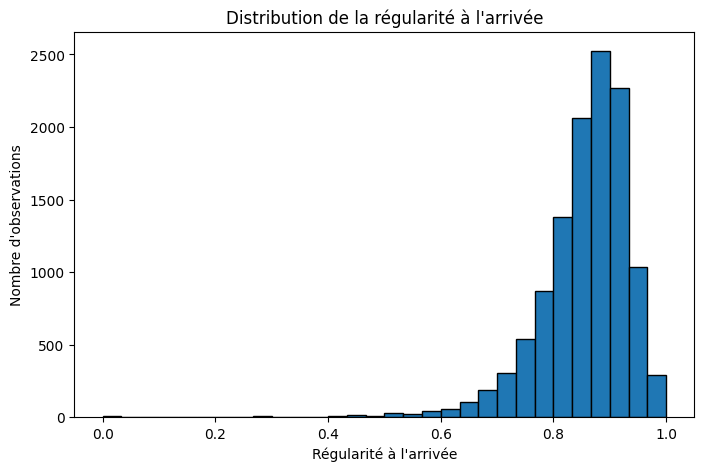

In [34]:
plt.figure(figsize=(8,5))

plt.hist(df_analyse["regularite_arrivee"], bins=30, edgecolor="black")

plt.xlabel("Régularité à l'arrivée")
plt.ylabel("Nombre d'observations")
plt.title("Distribution de la régularité à l'arrivée")

plt.show()

La distribution de la régularité à l’arrivée est fortement concentrée sur des valeurs élevées, principalement comprises entre 0,75 et 0,95.  
Cela indique que, dans la majorité des cas, une grande proportion des trains arrive sans retard.

On observe néanmoins une certaine dispersion, avec quelques observations présentant des niveaux de régularité plus faibles.  
Ces cas plus défavorables restent minoritaires, mais suggèrent l’existence de situations particulières où la ponctualité est dégradée.

La distribution apparaît légèrement asymétrique, avec une concentration importante autour de valeurs proches de 0,85–0,90.  
Cela confirme que la régularité des TGV est globalement bonne, tout en laissant apparaître des variations qui méritent d’être expliquées.



## Évolution de la régularité dans le temps

Nous étudions maintenant l'évolution de la régularité moyenne au fil des années.  
Cette analyse permet d’identifier d’éventuelles tendances ou ruptures dans la ponctualité des TGV.

In [36]:
regularite_par_annee = (
    df_analyse.groupby("annee", as_index=False)["regularite_arrivee"]
    .mean()
)

regularite_par_annee

,annee,regularite_arrivee
0,2018,0.819562
1,2019,0.855028
2,2020,0.865765
3,2021,0.888158
4,2022,0.854645
5,2023,0.851946
6,2024,0.861501
7,2025,0.844693


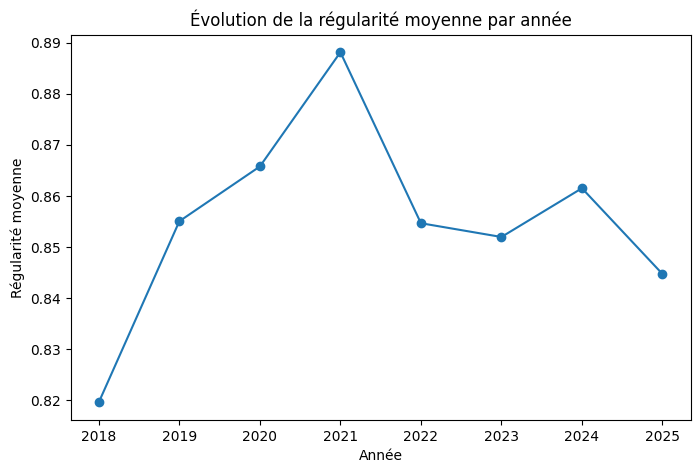

In [37]:

plt.figure(figsize=(8,5))

plt.plot(
    regularite_par_annee["annee"],
    regularite_par_annee["regularite_arrivee"],
    marker="o"
)

plt.xlabel("Année")
plt.ylabel("Régularité moyenne")
plt.title("Évolution de la régularité moyenne par année")

plt.show()

La régularité moyenne des TGV évolue au fil des années, avec des variations relativement marquées.

On observe d’abord une amélioration progressive de la régularité entre 2018 et 2020, avec un niveau maximal atteint autour de 2020.  
Cette période peut correspondre à une amélioration de l’exploitation ou à des conditions de trafic particulières.

À partir de 2020, une baisse de la régularité est observée. Cette évolution peut être liée à la crise sanitaire du COVID-19, qui a fortement perturbé le fonctionnement du transport ferroviaire (réorganisation des services, absences de personnel, adaptation de l’offre).

Les années suivantes montrent une certaine stabilisation, avec toutefois un niveau de régularité légèrement inférieur au pic observé avant la crise.

Ces résultats suggèrent que des facteurs conjoncturels, en particulier des événements exceptionnels comme la crise sanitaire, peuvent avoir un impact significatif sur la ponctualité des TGV.